In [25]:
import numpy as np 
import pandas as pd 
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

In [26]:
file="spam.csv"
df=pd.read_csv(file,encoding='latin-1')[['v1','v2']]
df.columns=['label','text']
df['label']=df['label'].map({'ham':0,'spam':1})
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# GNB

In [27]:
#Feature Engineering:Extract Numerical Features
df['text_length']=df['text'].apply(len)
df['num_words']=df['text'].apply(lambda x: len(x.split()))
df['num_digits']=df['text'].apply(lambda x: sum(c.isdigit() for c in x))
#Define features and target
x=df[['text_length','num_words','num_digits']]
y=df['label']
#split Dataset
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
#standardize the features
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
#Train Gaussian Naive Bayes Classifier
gnb=GaussianNB()
gnb.fit(x_train_scaled,y_train)
y_pred_gnb=gnb.predict(x_test_scaled)
#Evaluate the model 
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
print("Gaussian Naive Bayes Classifier Performance:")
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_gnb))
print("Classification Report:\n",classification_report(y_test,y_pred_gnb))
print("Accuracy:",accuracy_score(y_test,y_pred_gnb))

Gaussian Naive Bayes Classifier Performance:
Confusion Matrix:
 [[953  12]
 [ 10 140]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.92      0.93      0.93       150

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Accuracy: 0.9802690582959641


# MNB

In [ ]:
vectorizer=CountVectorizer(stop_words='english')
x_counts=vectorizer.fit_transform(df['text'])

tfidf_transformer=TfidfTransformer()
x_tfidf=tfidf_transformer.fit_transform(x_counts)

x_train,x_test,y_train,y_test=train_test_split(x_tfidf,df['label'],test_size=0.2,random_state=42)


mnb=MultinomialNB()
mnb.fit(x_train,y_train)
y_pred_mnb=mnb.predict(x_test)
print(y_pred_mnb)

print("multinomial Naive Bayes Classifier Performance:")
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_mnb))
print("Classification Report:\n",classification_report(y_test,y_pred_mnb))
print("Accuracy:",accuracy_score(y_test,y_pred_mnb))

[0 0 0 ... 0 0 1]
multinomial Naive Bayes Classifier Performance:
Confusion Matrix:
 [[965   0]
 [ 35 115]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Accuracy: 0.968609865470852


# BNB


In [30]:
important_words=["free","win","offer","money","urgent"]
for word in important_words:
    df[word]=df['text'].apply(lambda x: 1 if word in x.lower() else 0)
    
x=df[important_words]
y=df['label']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

bnb=BernoulliNB()
bnb.fit(x_train,y_train)
y_pred_bnb=bnb.predict(x_test)

print(y_pred_bnb)

print("bernoulli Naive Bayes Classifier Performance:")
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_bnb))
print("Classification Report:\n",classification_report(y_test,y_pred_bnb))
print("Accuracy:",accuracy_score(y_test,y_pred_bnb))

[0 0 0 ... 0 0 0]
bernoulli Naive Bayes Classifier Performance:
Confusion Matrix:
 [[929  36]
 [ 81  69]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       965
           1       0.66      0.46      0.54       150

    accuracy                           0.90      1115
   macro avg       0.79      0.71      0.74      1115
weighted avg       0.88      0.90      0.89      1115

Accuracy: 0.895067264573991


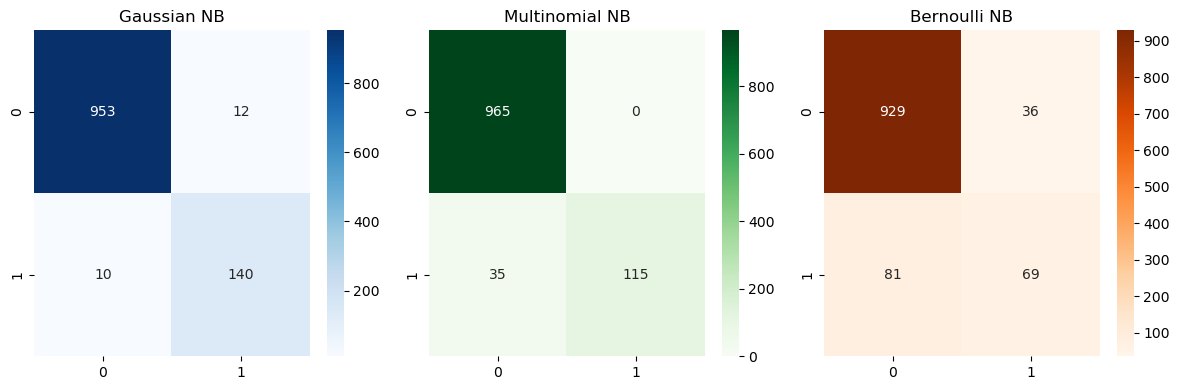

In [31]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.heatmap(confusion_matrix(y_test,y_pred_gnb),annot=True,fmt='d',cmap='Blues')
plt.title('Gaussian NB')
plt.subplot(1,3,2)
sns.heatmap(confusion_matrix(y_test,y_pred_mnb),annot=True,fmt='d',cmap='Greens')
plt.title('Multinomial NB')
plt.subplot(1,3,3)
sns.heatmap(confusion_matrix(y_test,y_pred_bnb),annot=True,fmt='d',cmap='Oranges')
plt.title('Bernoulli NB')
plt.tight_layout()
plt.show()